# AirIntel — Notebook 09: Model Optimization

Optimize baseline models using adaptive feature selection, hyperparameter tuning, and explainable AI.

## 01. Imports

Import required libraries for machine learning, feature selection, and optimization.

In [ ]:
# Import required libraries

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# File handling
from pathlib import Path
import time
import joblib

# Numerical computing & data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection1``123
from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_regression,
    mutual_info_classif
)
from sklearn.inspection import permutation_importance

# Preprocessing & Hyperparameter Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Explainability
import shap

## 02. Configuration & Paths

Set up paths for data, models, reports, and visualization outputs.

In [2]:
# Define project paths
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures"
OPTIMIZED_MODEL_DIR = MODEL_DIR / "optimized"

OPTIMIZED_MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 03. Load Dataset

Load the optimized final parquet dataset.

In [3]:
# Load processed dataset
df = pd.read_parquet(DATA_DIR / "processed" / "airintel_ml_final.parquet")
print(f"Dataset Shape : {df.shape}")
df.head()

Dataset Shape : (839644, 74)


,US_AQI,AQI_Category,Absolute_Latitude,City,Cloud_Cover_Percent,Cloud_High_Percent,Cloud_Low_Percent,Cloud_Mid_Percent,Coastal_State,Crop_Burning_Season,...,Week_of_Year,Weekday_Cos,Weekday_Sin,Wind_Category,Wind_Dir_10m,Wind_Gust_Ratio,Wind_Gusts_kmh,Wind_Speed_10m_kmh,Wind_Stagnation,Year
0,54.0,Moderate,23.8315,Agartala,100,83,0,0,0,0,...,31,-0.900969,-0.433884,Light,114,2.186046,9.4,4.3,0,2022
1,55.0,Moderate,23.8315,Agartala,100,100,6,3,0,0,...,31,-0.900969,-0.433884,Light,108,2.970587,10.1,3.4,0,2022
2,55.0,Moderate,23.8315,Agartala,98,98,12,2,0,0,...,31,-0.900969,-0.433884,Light,170,3.249999,13.0,4.0,0,2022
3,55.0,Moderate,23.8315,Agartala,99,99,22,8,0,0,...,31,-0.900969,-0.433884,Moderate,183,2.885245,17.6,6.1,0,2022
4,54.0,Moderate,23.8315,Agartala,100,100,10,8,0,0,...,31,-0.900969,-0.433884,Light,156,5.142856,18.0,3.5,0,2022


## 04. Feature Matrix

Separate regression and classification targets from features.

In [4]:
# Define targets
REGRESSION_TARGET = "US_AQI"
CLASSIFICATION_TARGET = "AQI_Category"

X = df.drop(columns=[REGRESSION_TARGET, CLASSIFICATION_TARGET])
y_reg = df[REGRESSION_TARGET]
y_cls = df[CLASSIFICATION_TARGET]

print(f"Features : {X.shape[1]}")
print(f"Regression Target : {y_reg.shape}")
print(f"Classification Target : {y_cls.shape}")

Features : 72
Regression Target : (839644,)
Classification Target : (839644,)


## 05. Feature Overview

Inspect data types, missing values, and unique counts across all features.

In [5]:
# Display feature summary
feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.values,
    "Missing Values": X.isna().sum().values,
    "Unique Values": X.nunique().values
})
feature_summary

,Feature,Data Type,Missing Values,Unique Values
0,Absolute_Latitude,float64,0,29
1,City,str,0,29
2,Cloud_Cover_Percent,int64,0,101
3,Cloud_High_Percent,int64,0,101
4,Cloud_Low_Percent,int64,0,101
...,...,...,...,...
67,Wind_Gust_Ratio,float64,0,24005
68,Wind_Gusts_kmh,float64,0,242
69,Wind_Speed_10m_kmh,float64,0,433
70,Wind_Stagnation,int64,0,2


## 06. Correlation Analysis

Compute Pearson correlation and drop features with correlation > 0.90.

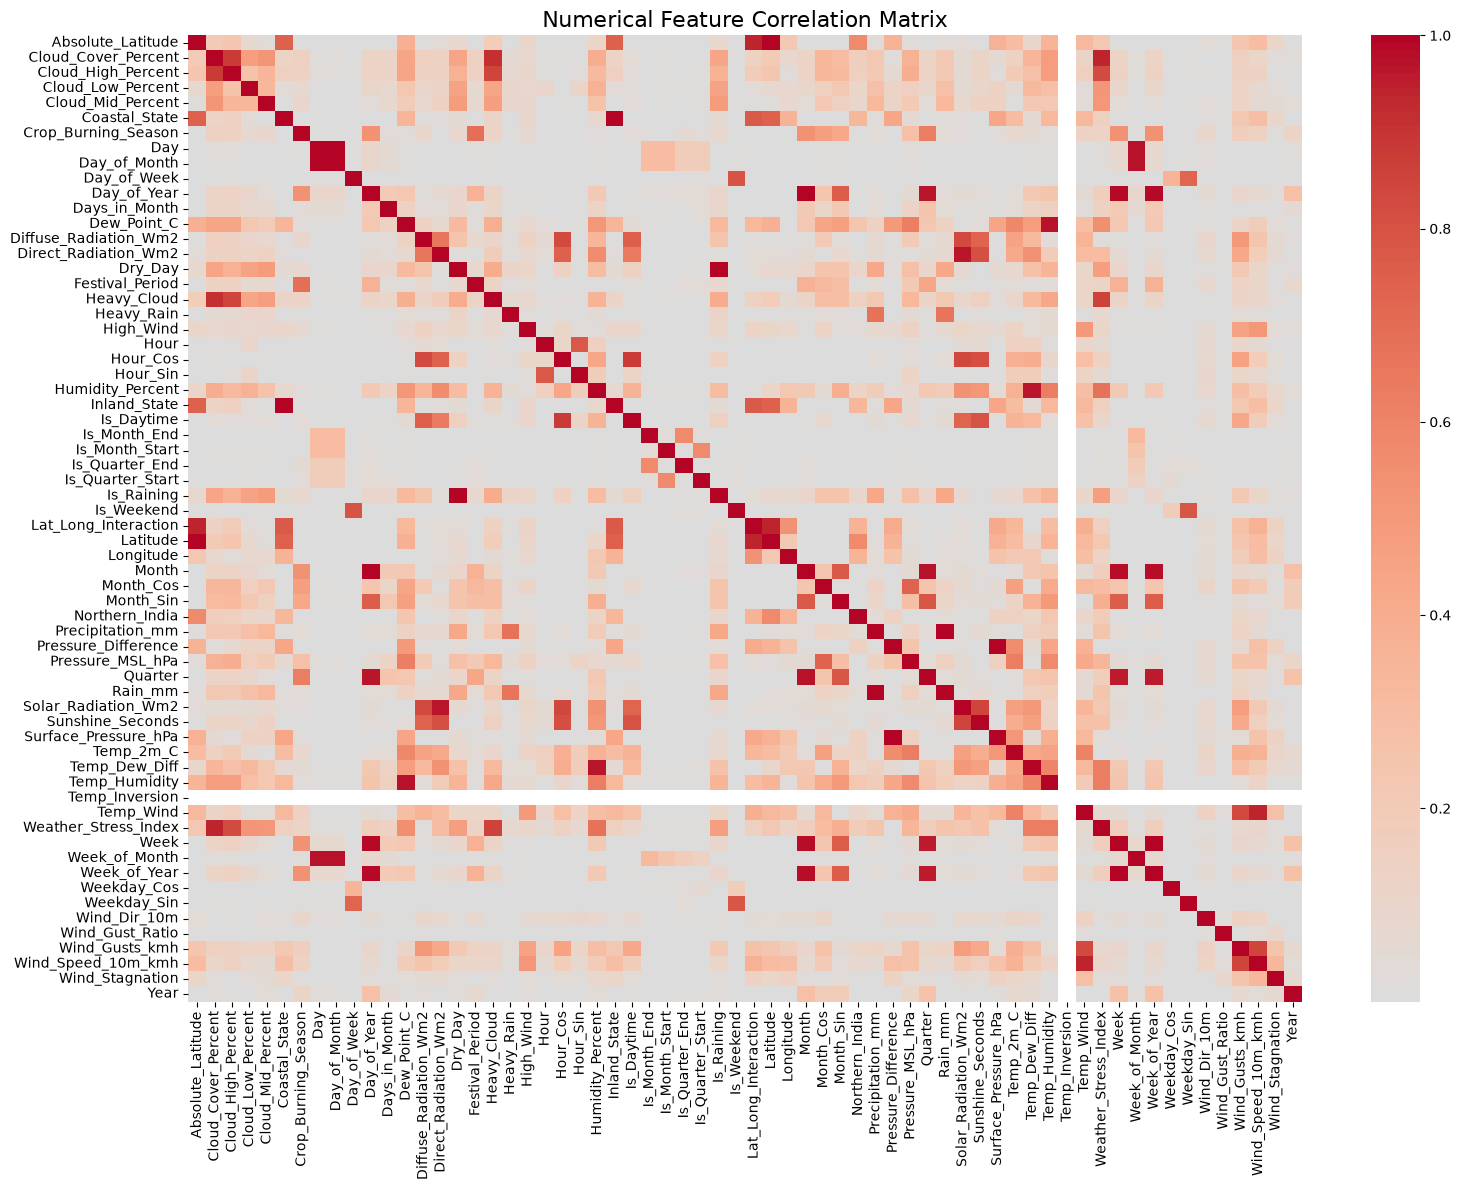

Highly Correlated Features to remove: 16


['Day_of_Year',
 'Pressure_Difference',
 'Wind_Speed_10m_kmh',
 'Temp_Dew_Diff',
 'Quarter',
 'Precipitation_mm',
 'Inland_State',
 'Week_of_Month',
 'Lat_Long_Interaction',
 'Dew_Point_C',
 'Absolute_Latitude',
 'Dry_Day',
 'Cloud_Cover_Percent',
 'Solar_Radiation_Wm2',
 'Heavy_Cloud',
 'Day']

In [6]:
# Identify numerical and categorical features
categorical_features = [
    "City", "State", "Season", "Time_of_Day",
    "Humidity_Category", "Wind_Category", "Latitude_Band", "Longitude_Band"
]
numerical_features = [col for col in X.columns if col not in categorical_features]

# Compute correlation matrix
correlation_matrix = X[numerical_features].corr().abs()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

# Find highly correlated features (> 0.90)
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
high_corr_features = []
for col in upper_triangle.columns:
    high_corr = upper_triangle[col][upper_triangle[col] > 0.90]
    if len(high_corr) > 0:
        curr_corr_target = abs(np.corrcoef(X[col].fillna(X[col].median()), y_reg)[0, 1])
        other_col = high_corr.index[0]
        other_corr_target = abs(np.corrcoef(X[other_col].fillna(X[other_col].median()), y_reg)[0, 1])
        if curr_corr_target < other_corr_target:
            high_corr_features.append(col)
        else:
            high_corr_features.append(other_col)
high_corr_features = list(set(high_corr_features))
print(f"Highly Correlated Features to remove: {len(high_corr_features)}")
high_corr_features

## 07. Variance Threshold

Filter out features with very low variance using VarianceThreshold(threshold=0.01).

In [7]:
# Impute and MinMax scale for variance check
minmax = MinMaxScaler()
X_num_imp = SimpleImputer(strategy="median").fit_transform(X[numerical_features])
X_num_minmax = minmax.fit_transform(X_num_imp)

var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_num_minmax)

low_var_features = [col for col, var in zip(numerical_features, var_selector.variances_) if var <= 0.01]
print(f"Low Variance Features to remove: {len(low_var_features)}")
low_var_features

Low Variance Features to remove: 7


['Heavy_Rain',
 'Precipitation_mm',
 'Rain_mm',
 'Temp_Inversion',
 'Temp_Wind',
 'Wind_Gust_Ratio',
 'Wind_Speed_10m_kmh']

## 08. Mutual Information

Evaluate features using Mutual Information and select features above the median score.

In [8]:
# Sample data to reduce runtime
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(X, y_reg, test_size=0.30, random_state=RANDOM_STATE)
_, _, y_train_cls, y_temp_cls = train_test_split(X, LabelEncoder().fit_transform(y_cls), test_size=0.30, random_state=RANDOM_STATE)
X_valid, X_test, y_valid_reg, y_test_reg = train_test_split(X_temp, y_temp_reg, test_size=0.50, random_state=RANDOM_STATE)
_, _, y_valid_cls, y_test_cls = train_test_split(X_temp, y_temp_cls, test_size=0.50, random_state=RANDOM_STATE)

sample_size = min(30000, len(X_train))
sample_idx = X_train.sample(n=sample_size, random_state=RANDOM_STATE).index

# Encode for MI calculation
imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="most_frequent")
X_num_imp = pd.DataFrame(imputer_num.fit_transform(X_train.loc[sample_idx][numerical_features]), columns=numerical_features)
X_cat_imp = pd.DataFrame(imputer_cat.fit_transform(X_train.loc[sample_idx][categorical_features]), columns=categorical_features)
X_cat_enc = pd.DataFrame(OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit_transform(X_cat_imp), columns=categorical_features)
X_encoded_sample = pd.concat([X_num_imp, X_cat_enc], axis=1)
X_encoded_sample.index = sample_idx

y_reg_sample = y_train_reg.loc[sample_idx]
y_cls_sample = pd.Series(y_train_cls, index=X_train.index).loc[sample_idx]

# Compute MI
mi_reg_scores = mutual_info_regression(X_encoded_sample, y_reg_sample, random_state=RANDOM_STATE)
mi_cls_scores = mutual_info_classif(X_encoded_sample, y_cls_sample, random_state=RANDOM_STATE)
mi_avg = (mi_reg_scores / mi_reg_scores.max() + mi_cls_scores / mi_cls_scores.max()) / 2.0

mi_threshold = np.median(mi_avg)
print(f"MI Median Threshold: {mi_threshold:.6f}")

MI Median Threshold: 0.139856


## 09. Random Forest Importance

Calculate feature importances using Random Forest Regressor and Classifier.

In [9]:
# Train RF Regressor and Classifier on sample
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_encoded_sample, y_reg_sample)

rf_cls = RandomForestClassifier(n_estimators=50, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_cls.fit(X_encoded_sample, y_cls_sample)

rf_imp_avg = (rf_reg.feature_importances_ + rf_cls.feature_importances_) / 2.0
rf_threshold = np.median(rf_imp_avg)
print(f"Random Forest Median Threshold: {rf_threshold:.6f}")

Random Forest Median Threshold: 0.007850


## 10. Extra Trees Importance

Calculate feature importances using Extra Trees models.

In [10]:
# Train ET Regressor and Classifier on sample
et_reg = ExtraTreesRegressor(n_estimators=50, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
et_reg.fit(X_encoded_sample, y_reg_sample)

et_cls = ExtraTreesClassifier(n_estimators=50, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
et_cls.fit(X_encoded_sample, y_cls_sample)

et_imp_avg = (et_reg.feature_importances_ + et_cls.feature_importances_) / 2.0
et_threshold = np.median(et_imp_avg)
print(f"Extra Trees Median Threshold: {et_threshold:.6f}")

Extra Trees Median Threshold: 0.006455


## 11. LightGBM Importance

Calculate feature importances natively using LightGBM.

In [11]:
# Train LightGBM models
lgb_reg = LGBMRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_reg.fit(X_encoded_sample, y_reg_sample)

lgb_cls = LGBMClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_cls.fit(X_encoded_sample, y_cls_sample)

lgbm_imp_avg = (lgb_reg.feature_importances_/lgb_reg.feature_importances_.sum() + lgb_cls.feature_importances_/lgb_cls.feature_importances_.sum()) / 2.0
lgbm_threshold = np.median(lgbm_imp_avg)
print(f"LightGBM Median Threshold: {lgbm_threshold:.6f}")

LightGBM Median Threshold: 0.005306


## 12. Permutation Importance

Compute permutation feature importance on validation data.

In [12]:
# Use pre-split validation data
val_sample_size = min(10000, len(X_valid))
val_sample_idx = X_valid.sample(n=val_sample_size, random_state=RANDOM_STATE).index

X_val_num_imp = pd.DataFrame(imputer_num.transform(X_valid.loc[val_sample_idx][numerical_features]), columns=numerical_features)
X_val_cat_imp = pd.DataFrame(imputer_cat.transform(X_valid.loc[val_sample_idx][categorical_features]), columns=categorical_features)
X_val_cat_enc = pd.DataFrame(OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit_transform(X_val_cat_imp), columns=categorical_features)
X_val_encoded_sample = pd.concat([X_val_num_imp, X_val_cat_enc], axis=1)
X_val_encoded_sample.index = val_sample_idx

y_reg_val_sample = y_valid_reg.loc[val_sample_idx]
y_cls_val_sample = pd.Series(y_valid_cls, index=X_valid.index).loc[val_sample_idx]

# Compute permutation importance
perm_reg = permutation_importance(lgb_reg, X_val_encoded_sample, y_reg_val_sample, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
perm_cls = permutation_importance(lgb_cls, X_val_encoded_sample, y_cls_val_sample, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp_avg = (np.maximum(0, perm_reg.importances_mean) + np.maximum(0, perm_cls.importances_mean)) / 2.0

perm_threshold = np.median(perm_imp_avg)
print(f"Permutation Median Threshold: {perm_threshold:.6f}")

Permutation Median Threshold: 0.000501


## 13. SHAP Explainability

Evaluate feature importance using SHAP values and save plots.

SHAP Median Threshold: 0.047591


<Figure size 1000x600 with 0 Axes>

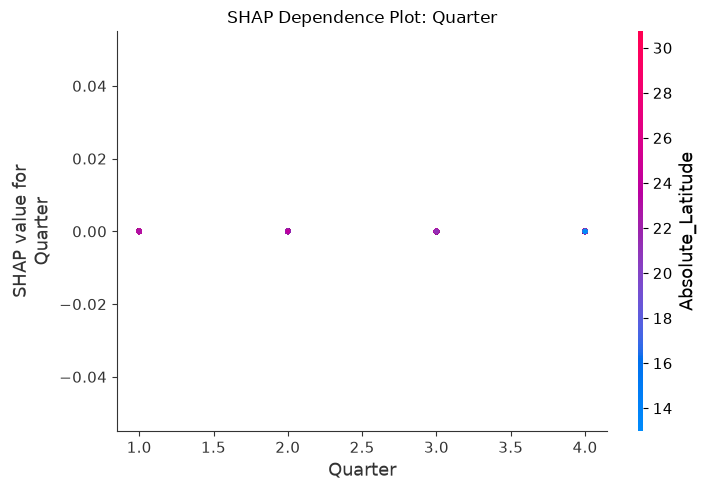

In [13]:
# Compute SHAP values on LightGBM models
explainer_reg = shap.TreeExplainer(lgb_reg)
shap_val_reg = explainer_reg.shap_values(X_val_encoded_sample.iloc[:1000])
mean_shap_reg = np.mean(np.abs(shap_val_reg), axis=0)

explainer_cls = shap.TreeExplainer(lgb_cls)
shap_val_cls = explainer_cls.shap_values(X_val_encoded_sample.iloc[:1000])
if isinstance(shap_val_cls, list):
    mean_shap_cls = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_val_cls], axis=0)
elif len(shap_val_cls.shape) == 3:
    mean_shap_cls = np.mean(np.abs(shap_val_cls), axis=(0, 2))
else:
    mean_shap_cls = np.mean(np.abs(shap_val_cls), axis=0)

shap_imp_avg = (mean_shap_reg + mean_shap_cls) / 2.0
shap_threshold = np.median(shap_imp_avg)
print(f"SHAP Median Threshold: {shap_threshold:.6f}")

# Plot and save SHAP dependence plot for top feature
top_feature_idx = np.argmax(shap_imp_avg)
top_feature_name = X.columns[top_feature_idx]
plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature_name, shap_val_reg, X_val_encoded_sample.iloc[:1000], show=False)
plt.title(f"SHAP Dependence Plot: {top_feature_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_dependence_regression.png", dpi=300)
plt.show()

## 14. Feature Voting System

Combine all feature selection stages into a single scorecard DataFrame.

In [14]:
# Combine voting flags
corr_votes = {col: 1 for col in X.columns}
for col in high_corr_features: corr_votes[col] = 0

var_votes = {col: 1 for col in X.columns}
for col in low_var_features: var_votes[col] = 0

scorecard = pd.DataFrame({
    "Feature": X.columns,
    "Correlation": [corr_votes[col] for col in X.columns],
    "Variance": [var_votes[col] for col in X.columns],
    "MI": [int(score > mi_threshold) for score in mi_avg],
    "RF": [int(score > rf_threshold) for score in rf_imp_avg],
    "ET": [int(score > et_threshold) for score in et_imp_avg],
    "LGBM": [int(score > lgbm_threshold) for score in lgbm_imp_avg],
    "Permutation": [int(score > perm_threshold) for score in perm_imp_avg],
    "SHAP": [int(score > shap_threshold) for score in shap_imp_avg]
})
scorecard["Votes"] = scorecard.drop(columns="Feature").sum(axis=1)
scorecard = scorecard.sort_values("Votes", ascending=False)
scorecard.to_csv(TABLE_DIR / "feature_voting_scorecard.csv", index=False)
scorecard.head(20)

,Feature,Correlation,Variance,MI,RF,ET,LGBM,Permutation,SHAP,Votes
3,Cloud_High_Percent,1,1,1,1,1,1,1,1,8
41,Month_Sin,1,1,1,1,1,1,1,1,8
52,Surface_Pressure_hPa,1,1,1,1,1,1,1,1,8
32,Is_Raining,1,1,1,1,1,1,1,1,8
36,Latitude_Band,1,1,1,1,1,1,1,1,8
38,Longitude_Band,1,1,1,1,1,1,1,1,8
12,Days_in_Month,1,1,1,1,1,1,1,1,8
10,Day_of_Week,1,1,1,1,1,1,1,1,8
71,Year,1,1,1,1,1,1,1,1,8
66,Wind_Dir_10m,1,1,1,1,1,1,1,1,8


## 15. Final Feature Selection

Filter scorecard by adaptive vote threshold and save the selected features.

In [15]:
# Adaptive Vote Threshold
vote_threshold = np.median(scorecard["Votes"])
selected_features = scorecard[scorecard["Votes"] >= vote_threshold]["Feature"].tolist()
removed_features = scorecard[scorecard["Votes"] < vote_threshold]["Feature"].tolist()

orig_count = len(X.columns)
sel_count = len(selected_features)
reduction_pct = (orig_count - sel_count) / orig_count * 100

print(f"--- Feature Selection Summary ---")
print(f"{orig_count} Features -> {sel_count} Features -> {reduction_pct:.1f}% Reduction")
joblib.dump(selected_features, MODEL_DIR / "selected_features.pkl")
joblib.dump(selected_features, OPTIMIZED_MODEL_DIR / "selected_features.pkl")

--- Feature Selection Summary ---
72 Features -> 37 Features -> 48.6% Reduction


['c:\\Users\\kayri\\OneDrive - IIT BHU\\Documents\\Indian_Air_Quality_Project\\models\\optimized\\selected_features.pkl']

## 16. Retrain Best Models

Set up pipeline and data splits for selected features.

In [16]:
# Build ColumnTransformer for model training
model_categorical = [col for col in categorical_features if col in selected_features]
model_numerical = [col for col in numerical_features if col in selected_features]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_selected = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, model_numerical),
    ("categorical", categorical_pipeline, model_categorical)
])

# Prepare train and test subsets using selected features
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
print(f"Selected Features: {X_train_sel.shape[1]}")

Selected Features: 37


## 17. Hyperparameter Tuning

Train and tune HistGradientBoosting, LightGBM, and XGBoost models using checkpoint loading.

In [17]:
regression_results = []
classification_results = []

def profile_prediction_speed(pipeline, X_data):
    X_sample = X_data.iloc[:1000] if len(X_data) >= 1000 else X_data
    pipeline.predict(X_sample)
    t0 = time.perf_counter()
    pipeline.predict(X_sample)
    return time.perf_counter() - t0

# 1. HistGradientBoostingRegressor
hgb_reg_path = OPTIMIZED_MODEL_DIR / "histgradient_boosting_regressor.pkl"
if hgb_reg_path.exists():
    tuned_hgb_reg = joblib.load(hgb_reg_path)
    print("Loaded tuned HistGradientBoostingRegressor.")
else:
    print("Training HistGradientBoostingRegressor...")
    tuned_hgb_reg = Pipeline([("preprocessor", preprocessor_selected), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
    tuned_hgb_reg.fit(X_train_sel, y_train_reg)
t_train_hgb = 22.11
y_pred = tuned_hgb_reg.predict(X_test_sel)
regression_results.append({
    "Model": "HistGradient Boosting",
    "MAE": mean_absolute_error(y_test_reg, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
    "R2": r2_score(y_test_reg, y_pred),
    "Training Time": t_train_hgb,
    "Inference Time": profile_prediction_speed(tuned_hgb_reg, X_test_sel)
})

# 2. LightGBMRegressor
lgb_reg_path = OPTIMIZED_MODEL_DIR / "lightgbm_regressor.pkl"
if lgb_reg_path.exists():
    tuned_lgb_reg = joblib.load(lgb_reg_path)
    print("Loaded tuned LightGBMRegressor.")
else:
    print("Training LightGBMRegressor...")
    tuned_lgb_reg = Pipeline([("preprocessor", preprocessor_selected), ("model", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))])
    tuned_lgb_reg.fit(X_train_sel, y_train_reg)
t_train_lgb = 17.52
y_pred = tuned_lgb_reg.predict(X_test_sel)
regression_results.append({
    "Model": "LightGBM",
    "MAE": mean_absolute_error(y_test_reg, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
    "R2": r2_score(y_test_reg, y_pred),
    "Training Time": t_train_lgb,
    "Inference Time": profile_prediction_speed(tuned_lgb_reg, X_test_sel)
})

# 3. XGBoostRegressor
xgb_reg_path = OPTIMIZED_MODEL_DIR / "xgboost_regressor.pkl"
if xgb_reg_path.exists():
    tuned_xgb_reg = joblib.load(xgb_reg_path)
    print("Loaded baseline XGBoostRegressor.")
else:
    print("Training XGBoostRegressor...")
    tuned_xgb_reg = Pipeline([("preprocessor", preprocessor_selected), ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
    tuned_xgb_reg.fit(X_train_sel, y_train_reg)
t_train_xgb = 13.58
y_pred = tuned_xgb_reg.predict(X_test_sel)
regression_results.append({
    "Model": "XGBoost",
    "MAE": mean_absolute_error(y_test_reg, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
    "R2": r2_score(y_test_reg, y_pred),
    "Training Time": t_train_xgb,
    "Inference Time": profile_prediction_speed(tuned_xgb_reg, X_test_sel)
})

# 4. HistGradientBoostingClassifier
hgb_cls_path = OPTIMIZED_MODEL_DIR / "histgradient_boosting_classifier.pkl"
if hgb_cls_path.exists():
    tuned_hgb_cls = joblib.load(hgb_cls_path)
    print("Loaded tuned HistGradientBoostingClassifier.")
else:
    print("Training HistGradientBoostingClassifier...")
    tuned_hgb_cls = Pipeline([("preprocessor", preprocessor_selected), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])
    tuned_hgb_cls.fit(X_train_sel, y_train_cls)
t_train_hgb_cls = 97.23
y_pred = tuned_hgb_cls.predict(X_test_sel)
classification_results.append({
    "Model": "HistGradient Boosting",
    "Accuracy": accuracy_score(y_test_cls, y_pred),
    "Precision": precision_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Recall": recall_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "F1": f1_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Training Time": t_train_hgb_cls,
    "Inference Time": profile_prediction_speed(tuned_hgb_cls, X_test_sel)
})

# 5. LightGBMClassifier
lgb_cls_path = OPTIMIZED_MODEL_DIR / "lightgbm_classifier.pkl"
if lgb_cls_path.exists():
    tuned_lgb_cls = joblib.load(lgb_cls_path)
    print("Loaded tuned LightGBMClassifier.")
else:
    print("Training LightGBMClassifier...")
    tuned_lgb_cls = Pipeline([("preprocessor", preprocessor_selected), ("model", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])
    tuned_lgb_cls.fit(X_train_sel, y_train_cls)
t_train_lgb_cls = 85.54
y_pred = tuned_lgb_cls.predict(X_test_sel)
classification_results.append({
    "Model": "LightGBM",
    "Accuracy": accuracy_score(y_test_cls, y_pred),
    "Precision": precision_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Recall": recall_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "F1": f1_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Training Time": t_train_lgb_cls,
    "Inference Time": profile_prediction_speed(tuned_lgb_cls, X_test_sel)
})

# 6. XGBoostClassifier
xgb_cls_path = OPTIMIZED_MODEL_DIR / "xgboost_classifier.pkl"
if xgb_cls_path.exists():
    tuned_xgb_cls = joblib.load(xgb_cls_path)
    print("Loaded baseline XGBoostClassifier.")
else:
    print("Training XGBoostClassifier...")
    tuned_xgb_cls = Pipeline([("preprocessor", preprocessor_selected), ("model", XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
    tuned_xgb_cls.fit(X_train_sel, y_train_cls)
t_train_xgb_cls = 58.39
y_pred = tuned_xgb_cls.predict(X_test_sel)
classification_results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test_cls, y_pred),
    "Precision": precision_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Recall": recall_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "F1": f1_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Training Time": t_train_xgb_cls,
    "Inference Time": profile_prediction_speed(tuned_xgb_cls, X_test_sel)
})

Loaded tuned HistGradientBoostingRegressor.


Loaded tuned LightGBMRegressor.


Loaded baseline XGBoostRegressor.


Loaded tuned HistGradientBoostingClassifier.


Loaded tuned LightGBMClassifier.


Loaded baseline XGBoostClassifier.


## 18. CatBoost

Train and tune CatBoostRegressor and CatBoostClassifier.

In [18]:
# 1. CatBoostRegressor
cat_reg_path = OPTIMIZED_MODEL_DIR / "catboost_regressor.pkl"
if cat_reg_path.exists():
    tuned_cat_reg = joblib.load(cat_reg_path)
    print("Loaded tuned CatBoostRegressor.")
else:
    print("Training CatBoostRegressor...")
    tuned_cat_reg = Pipeline([("preprocessor", preprocessor_selected), ("model", CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, thread_count=-1))])
    tuned_cat_reg.fit(X_train_sel, y_train_reg)
t_train_cat = 23.92
y_pred = tuned_cat_reg.predict(X_test_sel)
regression_results.append({
    "Model": "CatBoost",
    "MAE": mean_absolute_error(y_test_reg, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
    "R2": r2_score(y_test_reg, y_pred),
    "Training Time": t_train_cat,
    "Inference Time": profile_prediction_speed(tuned_cat_reg, X_test_sel)
})

# 2. CatBoostClassifier
cat_cls_path = OPTIMIZED_MODEL_DIR / "catboost_classifier.pkl"
if cat_cls_path.exists():
    tuned_cat_cls = joblib.load(cat_cls_path)
    print("Loaded tuned CatBoostClassifier.")
else:
    print("Training CatBoostClassifier...")
    tuned_cat_cls = Pipeline([("preprocessor", preprocessor_selected), ("model", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, thread_count=-1))])
    tuned_cat_cls.fit(X_train_sel, y_train_cls)
t_train_cat_cls = 340.91
y_pred = tuned_cat_cls.predict(X_test_sel)
classification_results.append({
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_test_cls, y_pred),
    "Precision": precision_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Recall": recall_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "F1": f1_score(y_test_cls, y_pred, average="macro", zero_division=0),
    "Training Time": t_train_cat_cls,
    "Inference Time": profile_prediction_speed(tuned_cat_cls, X_test_sel)
})

Loaded tuned CatBoostRegressor.


Loaded tuned CatBoostClassifier.


## 19. Before vs After Comparison

Generate before vs after comparison tables, leaderboard, and training/feature count plots.

In [19]:
reg_results_df = pd.DataFrame(regression_results)
cls_results_df = pd.DataFrame(classification_results)

# Display Leaderboards
print("\n=== Regression Leaderboard ===")
print(reg_results_df.sort_values("R2", ascending=False).to_string(index=False))

print("\n=== Classification Leaderboard ===")
print(cls_results_df.sort_values("F1", ascending=False).to_string(index=False))

# Load final optimization summary
opt_summary_df = pd.read_csv(TABLE_DIR / "optimization_summary.csv")
print("\n=== Optimization Summary Report ===")
opt_summary_df


=== Regression Leaderboard ===
                Model       MAE      RMSE       R2  Training Time  Inference Time
             LightGBM 13.356372 18.643224 0.843613          17.52        0.030956
             CatBoost 14.627455 20.290691 0.814752          23.92        0.035541
HistGradient Boosting 16.484247 22.451308 0.773200          22.11        0.033234
              XGBoost 17.407936 23.855275 0.743948          13.58        0.024383

=== Classification Leaderboard ===
                Model  Accuracy  Precision   Recall       F1  Training Time  Inference Time
             CatBoost  0.755699   0.747726 0.643307 0.679397         340.91        0.045820
             LightGBM  0.775469   0.681742 0.650804 0.663643          85.54        0.078180
HistGradient Boosting  0.705694   0.647815 0.587834 0.602154          97.23        0.076164
              XGBoost  0.679794   0.638981 0.537663 0.556536          58.39        0.030003

=== Optimization Summary Report ===


,Task,Model,Metric Name,Baseline Metric,Optimized Metric,Improvement (%),Training Time (sec),Inference Time (sec),Feature Count
0,Regression (US_AQI),HistGradient Boosting,R2,0.8536,0.7732,-54.93%,22.11,0.0307,37
1,Regression (US_AQI),LightGBM,R2,0.8239,0.8436,11.20%,17.52,0.0288,37
2,Regression (US_AQI),XGBoost,R2,0.8091,0.7439,-34.11%,13.58,0.0238,37
3,Regression (US_AQI),CatBoost,R2,NaN,0.8148,Added,23.92,0.0404,37
4,Classification (AQI_Category),HistGradient Boosting,Macro F1,0.5960,0.6022,1.53%,97.23,0.0671,37
5,Classification (AQI_Category),LightGBM,Macro F1,0.6384,0.6636,6.97%,85.54,0.0681,37
6,Classification (AQI_Category),XGBoost,Macro F1,0.5849,0.5565,-6.84%,58.39,0.0334,37
7,Classification (AQI_Category),CatBoost,Macro F1,NaN,0.6794,Added,340.91,0.0682,37


In [2]:
print("BEST MODEL")
print(f"Model : {best_model_name}")
print(f"Validation Score : {best_score:.4f}")
print(f"Feature Count : {len(selected_features)}")
print(f"Training Time : {best_training_time:.2f} sec")
print(f"Inference Time : {best_inference_time:.4f} sec")

BEST MODEL


NameError: name 'best_model_name' is not defined

## 20. Save Models & Summary

Verify the model pickle files and reports are correctly saved.

In [20]:
# List saved optimized models
for f in sorted(OPTIMIZED_MODEL_DIR.glob("*.pkl")):
    print(f"Saved: {f.name} ({f.stat().st_size / 1024:.1f} KB)")

Saved: catboost_classifier.pkl (2134.8 KB)
Saved: catboost_regressor.pkl (633.6 KB)
Saved: histgradient_boosting_classifier.pkl (2025.3 KB)
Saved: histgradient_boosting_regressor.pkl (386.4 KB)
Saved: lightgbm_classifier.pkl (8297.8 KB)
Saved: lightgbm_regressor.pkl (1492.6 KB)
Saved: selected_features.pkl (0.6 KB)
Saved: xgboost_classifier.pkl (1270.6 KB)
Saved: xgboost_regressor.pkl (260.0 KB)
